In [143]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys
from tqdm.auto import tqdm
sys.path.insert(0, os.path.abspath("../fsrs-optimizer/src/fsrs_optimizer/"))
import numpy as np
from sklearn.model_selection import train_test_split

tqdm.pandas()

In [144]:
# Review count: User id
# Median: 8798
# Most: 6810

USER_ID = 300
df = pd.read_parquet(
    "../anki-revlogs-10k/revlogs", filters=[("user_id", "=", USER_ID), ("rating", "in", [1, 2, 3, 4])], columns=["card_id", "day_offset", "rating", "elapsed_days", "duration"] 
)
df["y"] = df["rating"].map({1: 0, 2: 1, 3: 1, 4: 1})
df.size

38178

In [145]:
df_filtered = df[(df["elapsed_days"] > 0)]

In [146]:
groups = df_filtered.groupby("rating")["duration"].median()

df_filtered["review_average"] = df_filtered["rating"].map(groups)

current_residual = df_filtered.groupby("rating").apply(lambda x: abs(x["duration"] - x["review_average"]).mean())

current_residual, groups

/tmp/ipykernel_102381/2144162587.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["review_average"] = df_filtered["rating"].map(groups)
/tmp/ipykernel_102381/2144162587.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  current_residual = df_filtered.groupby("rating").apply(lambda x: abs(x["duration"] - x["review_average"]).mean())


(rating
 1     7243.772834
 2    11610.891304
 3     5467.750927
 4        0.000000
 dtype: float64,
 rating
 1    6899.0
 2    9348.0
 3    5691.5
 4    2090.0
 Name: duration, dtype: float64)

In [147]:
columns = ["duration", "review_average", "y"]

day_accuracies = df_filtered.groupby("day_offset")[columns]
unique_days = df_filtered["day_offset"].unique()

train_days, test_days = train_test_split(unique_days)

train_df = df_filtered[df_filtered["day_offset"].isin(train_days)]
test_df = df_filtered[df_filtered["day_offset"].isin(test_days)]

train_groups = train_df.groupby("day_offset")[columns]
test_groups = test_df.groupby("day_offset")[columns]

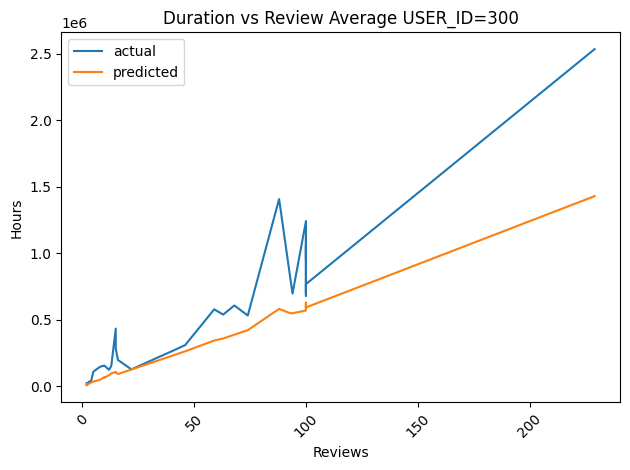

In [148]:
import matplotlib.pyplot as plt

def counts_sums(groups):
    # Compute count and sum
    counts = groups.count()
    sums = groups.sum()

    # Sort by count of 'duration' (or 'review_average' – whichever makes sense)
    sorted_indices = counts["duration"].sort_values().index

    # Reorder both sums and counts to match
    counts = counts.loc[sorted_indices]
    sums = sums.loc[sorted_indices]
    return counts, sums

counts, sums = counts_sums(day_accuracies)

# Plot
plt.plot(counts["duration"], sums["duration"], label="actual")
plt.plot(counts["review_average"], sums["review_average"], label="predicted")

plt.xlabel("Reviews")
plt.ylabel("Hours")
plt.title(f"Duration vs Review Average {USER_ID=}")
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()


# Find trend

An idea where the days with higher duration may have less or more inaccuracy but there doesn't seem to be a correlation

array([-0.00448982,  2.04969526])

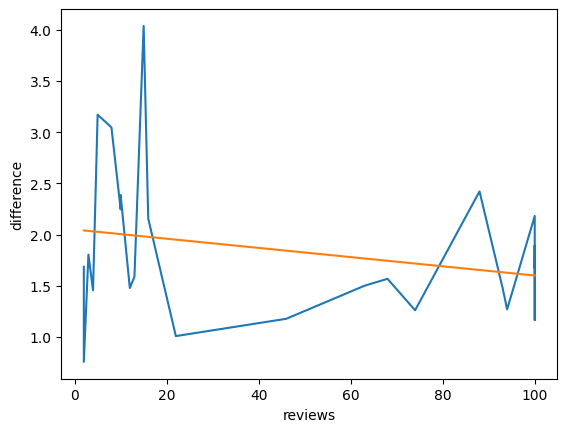

In [149]:
import numpy as np

counts, sums = counts_sums(train_groups)

difference = sums["duration"] / sums["review_average"]
plt.plot(counts["review_average"], difference, label="error")
c = np.polyfit(counts["review_average"], difference, 1)
adjustment = np.polyval(c, counts["review_average"])
plt.plot(counts["review_average"], adjustment, label="adjustment")
plt.xlabel("reviews")
plt.ylabel("difference")
c

# Rating medians

('Mean error', 'before', np.float64(199671.25))

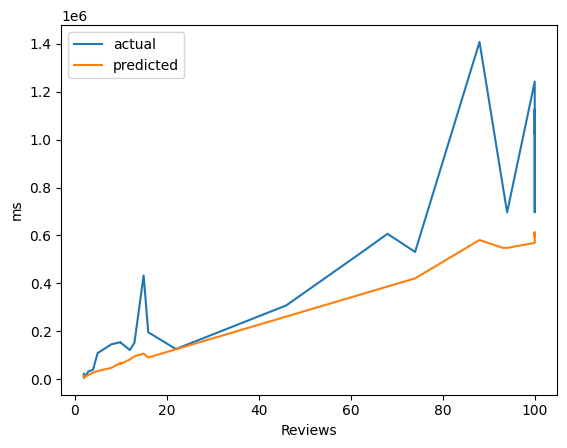

In [ ]:
plt.plot(counts["duration"], sums["duration"], label="actual")
plt.plot(counts["review_average"], sums["review_average"], label="predicted")

plt.xlabel("Reviews")
plt.ylabel("ms")

plt.legend()
"Mean error", "before", abs(sums["duration"] - sums["review_average"]).mean()

# Calculated multiplier

If you take the average difference between the predicted values and the actual values on a day to day basis, you can use that as a multiplier to make the timings more accurate.

(np.float64(1.8341837509709733),
 'Mean error',
 'before',
 np.float64(303669.1666666667),
 'after',
 np.float64(190911.5772438307))

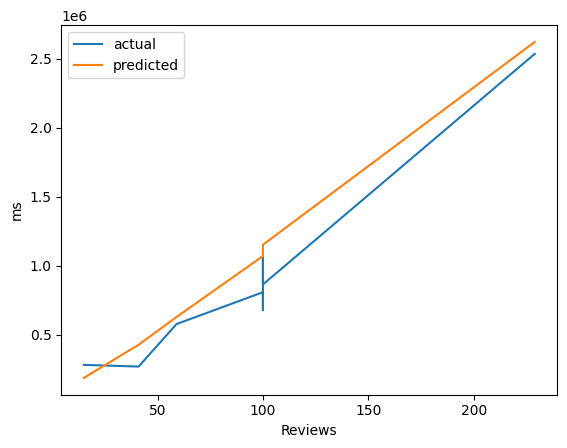

In [151]:
counts, sums = counts_sums(train_groups)
loss_aversion_mean = (sums["duration"] / sums["review_average"]).mean()
loss_aversion_mean_squared = (sums["duration"] / sums["review_average"]).mean()

counts, sums = counts_sums(test_groups)

plt.plot(counts["duration"], sums["duration"], label="actual")
plt.plot(counts["review_average"], sums["review_average"] * loss_aversion_mean, label="predicted")
plt.xlabel("Reviews")
plt.ylabel("ms")
plt.legend()

loss_aversion_mean, "Mean error", "before", abs(sums["duration"] - sums["review_average"]).mean(), "after", (abs(sums["duration"] - (sums["review_average"]) * loss_aversion_mean)).mean()

# Rating medians * review adjustment

('Mean error',
 'before',
 np.float64(303669.1666666667),
 'after',
 np.float64(241779.57724982282))

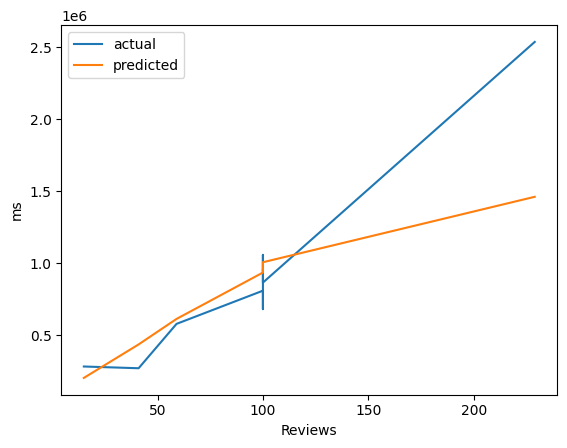

In [152]:

counts, sums = counts_sums(test_groups)
adjustment = np.polyval(c, counts["review_average"])

plt.plot(counts["duration"], sums["duration"], label="actual")
plt.plot(counts["review_average"], sums["review_average"] * adjustment, label="predicted")
plt.xlabel("Reviews")
plt.ylabel("ms")
plt.legend()

"Mean error", "before", abs(sums["duration"] - sums["review_average"]).mean(), "after", (abs(sums["duration"] - (sums["review_average"]) * adjustment)).mean()

# True retention to duration per day

array([-1373.74787066,  7126.97748721])

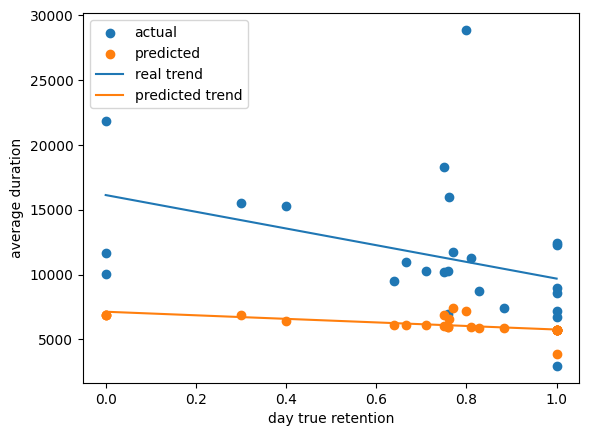

In [160]:
counts, sums = counts_sums(train_groups)

# 1️⃣  Compute retention (you already have this):
retention = sums["y"] / counts["y"]

# 2️⃣  Get the index order that sorts retention (⇧ descending keeps the best-retaining groups first)
order = retention.sort_values(ascending=False).index

# 3️⃣  Re-index everything in that order
counts_sorted    = counts.loc[order]
sums_sorted      = sums.loc[order]
retention_sorted = retention.loc[order]

# ↪️  Now counts_sorted.index == sums_sorted.index == retention_sorted.index,
#     all arranged from highest to lowest retention.

average_real = sums_sorted["duration"] / counts_sorted["duration"]
average_predicted = sums_sorted["review_average"] / counts_sorted["review_average"]

c = np.polyfit(retention_sorted, sums_sorted["review_average"] / counts_sorted["review_average"], 1)
c2 = np.polyfit(retention_sorted, sums_sorted["duration"] / counts_sorted["duration"], 1)
plt.scatter(retention_sorted, average_real, label="actual")
plt.scatter(retention_sorted, average_predicted, label="predicted")
plt.plot(retention_sorted, np.polyval(c2, retention_sorted), label="real trend")
plt.plot(retention_sorted, np.polyval(c, retention_sorted), label="predicted trend")
plt.legend()
plt.ylabel("average duration")
plt.xlabel("day true retention")
plt.axis()
c

array([-0.67456752,  2.31645274])

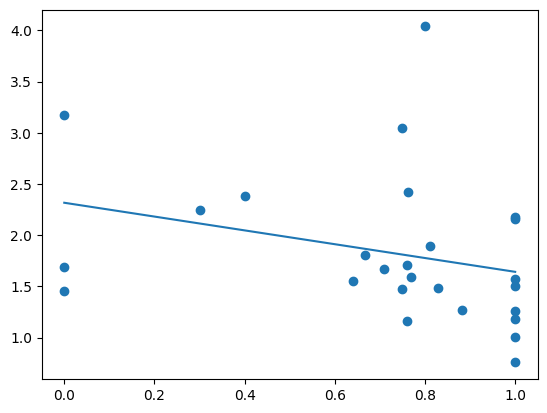

In [154]:
inaccuracy_factor = average_real / average_predicted
c = np.polyfit(retention_sorted, inaccuracy_factor, 1)
plt.scatter(retention_sorted, inaccuracy_factor, label="predicted")
plt.plot(retention_sorted, np.polyval(c, retention_sorted))
c

('Mean error',
 'before',
 np.float64(303669.1666666667),
 'after',
 np.float64(233678.3589050793))

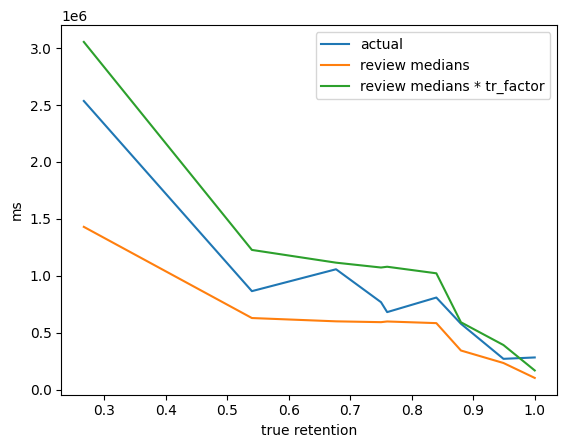

In [155]:
counts, sums = counts_sums(test_groups)

# 1️⃣  Compute retention (you already have this):
retention = sums["y"] / counts["y"]

# 2️⃣  Get the index order that sorts retention (⇧ descending keeps the best-retaining groups first)
order = retention.sort_values(ascending=False).index

# 3️⃣  Re-index everything in that order
counts_sorted    = counts.loc[order]
sums_sorted      = sums.loc[order]
retention_sorted = retention.loc[order]

retention_adjustment = np.polyval(c, retention_sorted)

plt.plot(retention_sorted, sums["duration"], label="actual")
plt.plot(retention_sorted, sums["review_average"], label="review medians")
plt.plot(retention_sorted, sums["review_average"] * retention_adjustment, label="review medians * tr_factor")
plt.legend()
plt.ylabel("ms")
plt.xlabel("true retention")

"Mean error", "before", abs(sums["duration"] - sums["review_average"]).mean(), "after", (abs(sums["duration"] - (sums["review_average"]) * retention_adjustment)).mean()

# Use day true retention card by card

# Pretty much ignore this I think

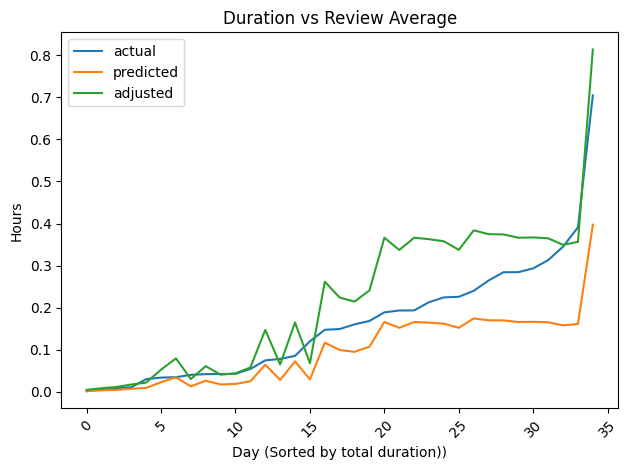

In [156]:
import matplotlib.pyplot as plt

# Group, sample, and prepare data
day_accuracies = df_filtered.groupby("day_offset")[["duration", "review_average"]].sum()
day_accuracies.sort_values("duration", inplace=True)
day_accuracies.reset_index(inplace=True)

# Optionally convert units now
day_accuracies["duration"] /= (1000 * 60 * 60)        # convert to hours
day_accuracies["review_average"] /= (1000 * 60 * 60)  # convert to hours
adjustment = np.polyval(c, day_accuracies["review_average"])

plt.plot(day_accuracies.index, day_accuracies["duration"], label="actual")
plt.plot(day_accuracies.index, day_accuracies["review_average"], label="predicted")
plt.plot(day_accuracies.index, day_accuracies["review_average"] * adjustment, label="adjusted")

plt.xlabel("Day (Sorted by total duration))")
plt.ylabel("Hours")
plt.title("Duration vs Review Average")
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()
